# Treasury Yield Curve Simulation
## PCA-Based Monte Carlo for Investment Decision Support

### The Big Idea

We want to answer: **"Where on the yield curve should I invest?"**

To do it rigorously, we simulate thousands of possible yield curve futures, then measure how each maturity performs across those futures — capturing carry, roll-down, and price risk in one framework.

### Three Phases

| Phase | What we do | Why |
|-------|-----------|-----|
| **1. PCA** | Compress 6+ correlated yields into 3 independent "drivers" | Yields don't move independently — 3 factors explain >99% of all moves |
| **2. Monte Carlo** | Simulate 1,000 yield curve paths over 1 year | Gives us a *distribution* of futures, not just a point estimate |
| **3. Total Return** | Carry + roll-down + price change per tenor, per path | Shows which maturity wins most often and by how much |

### The 3 Classic Yield Curve Factors (preview)

- **Level (PC1 ~90%)** — All tenors shift up/down together. Driven by inflation expectations and Fed policy.
- **Slope (PC2 ~8%)** — Short end vs. long end diverge. Driven by growth outlook and hiking/cutting cycles.
- **Curvature (PC3 ~2%)** — Belly moves relative to wings. Driven by convexity demand and butterfly trades.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import interpolate

plt.style.use('seaborn-v0_8-darkgrid')
PC_COLORS = ['steelblue', 'darkorange', 'green']

# ---------------------------------------------------------------------------
# Load treasury yields from dedicated sheet
# ---------------------------------------------------------------------------
master_path = "../data/master_workbook.xlsx"

df_tsy = pd.read_excel(master_path, sheet_name="Treasuries_all", index_col=0)
df_tsy.index = pd.to_datetime(df_tsy.index)
df_tsy = df_tsy.sort_index()
df_tsy = df_tsy.apply(pd.to_numeric, errors='coerce')
df_tsy = df_tsy.dropna(how='all').dropna(axis=1, how='all')

# ---------------------------------------------------------------------------
# Map column names → (display label, maturity in years)
# ---------------------------------------------------------------------------
KNOWN_TENORS = {
    '1 Mo':  ('1M',  1/12),  'DGS3MO':  ('3M',  0.25),
    '6 Mo':  ('6M',  0.5),   'DGS1':    ('1Y',  1.0),
    '2 Yr':    ('2Y',  2.0),   'DGS3':    ('3Y',  3.0),
    '5 Yr':    ('5Y',  5.0),   'DGS7':    ('7Y',  7.0),
    '10 Yr':   ('10Y', 10.0),  'DGS20':   ('20Y', 20.0),
    '30 Yr':   ('30Y', 30.0),
}

col_labels, col_years = [], []
rename_map = {}

for col in df_tsy.columns:
    if col in KNOWN_TENORS:
        lbl, yrs = KNOWN_TENORS[col]
        rename_map[col] = lbl
        col_labels.append(lbl)
        col_years.append(yrs)
    else:
        col_labels.append(str(col))
        col_years.append(None)

df_tsy = df_tsy.rename(columns=rename_map)

assert any(y is not None for y in col_years), \
    f"Could not detect tenor maturities. Columns found: {list(df_tsy.columns)}"

tenor_pairs = sorted(
    [(lbl, yrs, col) for lbl, yrs, col in zip(col_labels, col_years, df_tsy.columns) if yrs is not None],
    key=lambda x: x[1]
)
col_labels = [t[0] for t in tenor_pairs]
col_years  = [t[1] for t in tenor_pairs]
df_tsy     = df_tsy[[t[2] for t in tenor_pairs]].dropna()
df_tsy.columns = col_labels

print(f"Loaded: {df_tsy.index[0].date()} → {df_tsy.index[-1].date()}  ({len(df_tsy):,} trading days)")
print(f"Tenors: {col_labels}")
df_tsy.tail(3)

Loaded: 2024-01-02 → 2026-03-23  (554 trading days)
Tenors: ['1M', '6M', '2Y', '5Y', '10Y', '30Y']


,1M,6M,2Y,5Y,10Y,30Y
Date,,,,,,
2026-03-19,3.73,3.76,3.79,3.88,4.25,4.83
2026-03-20,3.73,3.79,3.88,4.01,4.39,4.96
2026-03-23,3.73,3.77,3.83,3.95,4.34,4.91


## Step 1: Understand Your Data

Before modeling anything, always look at what you have. Two views matter:

1. **Time series** — how each tenor has evolved over history. This is the universe of environments you're calibrating from. Notice the 2022 hiking cycle, the 2020 zero-rate era, the 2018–19 inversion.
2. **Current curve shape** — today's starting point for all simulations. Compare it to 1Y and 2Y ago to understand the regime you're in.

**What to look for:**
- Is the curve inverted (short > long)? That hurts roll-down — you *lose* return as a bond ages through an inverted curve.
- How wide is the historical range? That calibrates the "how bad can it get" question.
- Are there structural breaks? Pre-2008 rates were in a different regime — consider trimming your lookback if it changes the story.

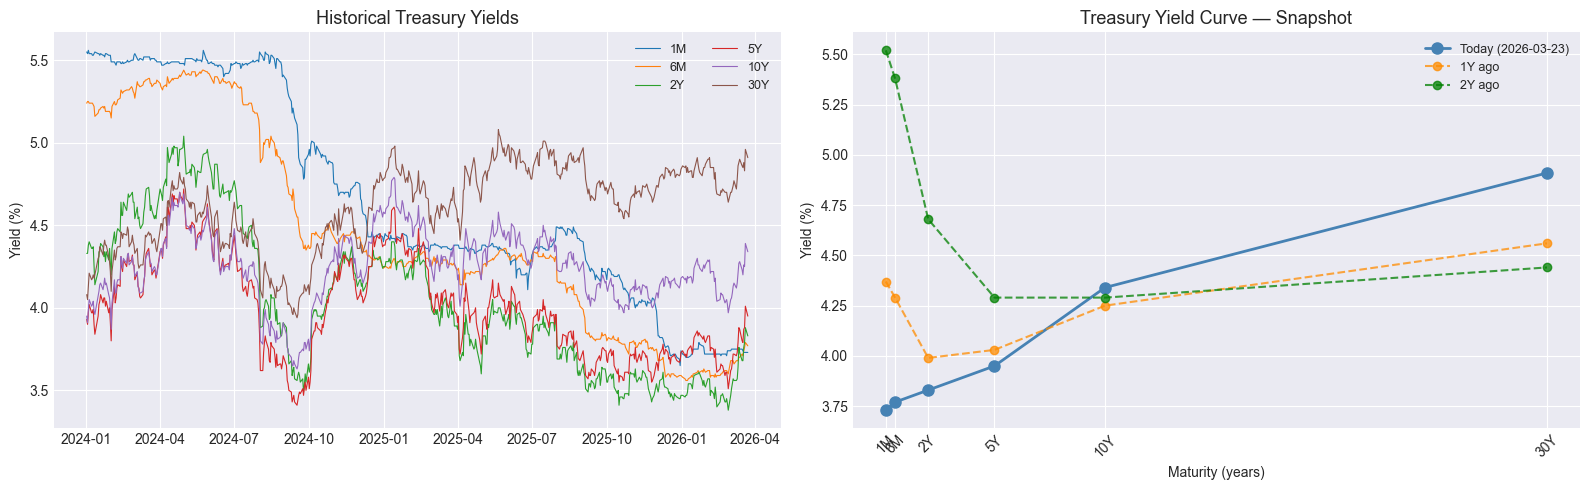

Current yields:
  1M   ( 0.08yr): 3.730%
  6M   ( 0.50yr): 3.770%
  2Y   ( 2.00yr): 3.830%
  5Y   ( 5.00yr): 3.950%
  10Y  (10.00yr): 4.340%
  30Y  (30.00yr): 4.910%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Historical time series per tenor ---
ax = axes[0]
for col in df_tsy.columns:
    ax.plot(df_tsy.index, df_tsy[col], linewidth=0.8, label=col)
ax.set_title("Historical Treasury Yields", fontsize=13)
ax.set_ylabel("Yield (%)")
ax.legend(fontsize=9, ncol=2)

# --- Right: Current yield curve vs. 1Y and 2Y ago ---
ax2 = axes[1]
current = df_tsy.iloc[-1]
ax2.plot(col_years, current.values, 'o-', lw=2, ms=8, color='steelblue',
         label=f"Today ({df_tsy.index[-1].date()})")

for lookback, label, color in [(252, '1Y ago', 'darkorange'), (504, '2Y ago', 'green')]:
    if len(df_tsy) > lookback:
        past = df_tsy.iloc[-lookback]
        ax2.plot(col_years, past.values, 'o--', lw=1.5, ms=6, color=color, alpha=0.75, label=label)

ax2.set_title("Treasury Yield Curve — Snapshot", fontsize=13)
ax2.set_ylabel("Yield (%)")
ax2.set_xlabel("Maturity (years)")
ax2.set_xticks(col_years)
ax2.set_xticklabels(col_labels, rotation=45)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Quick stats on current curve
print("Current yields:")
for lbl, yrs, yld in zip(col_labels, col_years, current.values):
    print(f"  {lbl:4s} ({yrs:5.2f}yr): {yld:.3f}%")

## Step 2: Yield Changes — Not Levels

We model daily yield **changes** (Δy), not yield levels. Three reasons:

**1. Stationarity** — Yield levels trend over decades (15% in 1981 → 0% in 2020). Statistical models break down on trending data. Changes don't trend — they hover around zero. This makes them suitable for Monte Carlo.

**2. Near-normal distribution** — Yield changes are approximately bell-shaped, which is what we need to simulate with random draws from a normal distribution.

**3. Interpretability** — Markets quote moves in **basis points** (bps). 1 bp = 0.01%. A +10 bps move on the 10Y means yields went from 4.50% → 4.60%.

We use **absolute changes** (not log-returns) because yields can be near zero, and log(near-zero) is numerically unstable.

> **Key insight:** The *covariance matrix* of these daily changes is exactly what PCA will decompose in the next step.

Daily yield change statistics:

                      1M     6M     2Y     5Y    10Y    30Y
Mean (bps/day)     -0.33  -0.27  -0.09   0.00   0.07   0.15
Std Dev (bps/day)   2.37   2.46   5.61   5.69   5.23   4.95
Min (bps)         -14.00 -20.00 -28.00 -22.00 -19.00 -16.00
Max (bps)          11.00  10.00  23.00  24.00  19.00  17.00


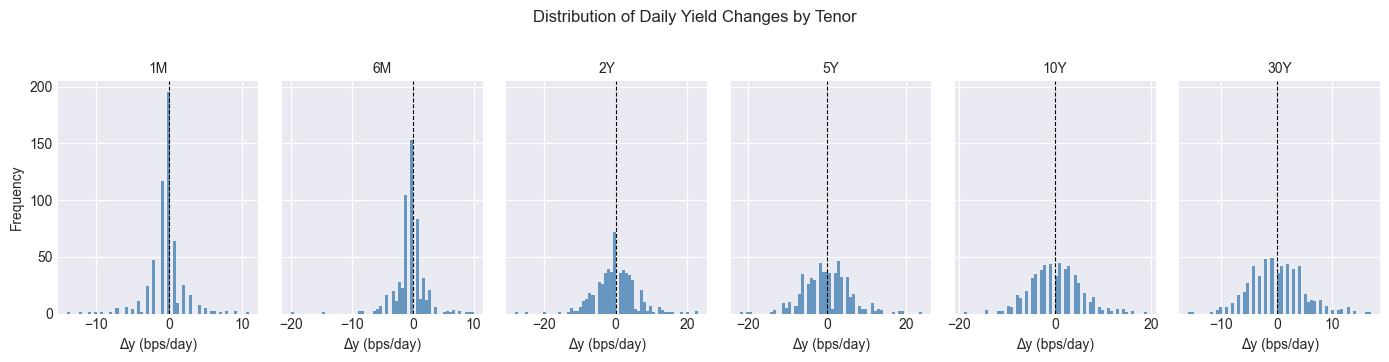

In [ ]:
# Daily absolute yield changes (% units — same as bps/100)
dy = df_tsy.diff().dropna()

# --- Summary statistics ---
stats = pd.DataFrame({
    'Mean (bps/day)': (dy.mean() * 100).round(2),
    'Std Dev (bps/day)': (dy.std() * 100).round(2),
    'Min (bps)': (dy.min() * 100).round(1),
    'Max (bps)': (dy.max() * 100).round(1),
}).T
print("Daily yield change statistics:\n")
print(stats.to_string())

# --- Distribution histograms ---
n_cols = len(col_labels)
fig, axes = plt.subplots(1, n_cols, figsize=(max(14, n_cols * 2), 3.5), sharey=True)
if n_cols == 1:
    axes = [axes]

for i, col in enumerate(col_labels):
    data_bps = dy.iloc[:, i] * 100
    axes[i].hist(data_bps, bins=60, color='steelblue', alpha=0.8, edgecolor='none')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Δy (bps/day)')
    axes[i].axvline(0, color='black', linewidth=0.8, linestyle='--')
    if i == 0:
        axes[i].set_ylabel('Frequency')

plt.suptitle("Distribution of Daily Yield Changes by Tenor", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## Step 3: PCA — Finding the Hidden Factors

This is the mathematical core of the model. Here's the intuition first:

When you watch the yield curve move every day, you notice the changes aren't random and independent across tenors — when the 2Y rises, the 10Y usually rises too. PCA finds the hidden "master levers" that explain those correlated moves.

**How PCA works (conceptually):**

> "Find the directions in yield-change space where the most variance lives."

- **Loadings (eigenvectors):** The *shape* of each factor — how it moves each tenor. E.g., PC1 might push all tenors up by similar amounts.
- **Factor scores:** How much each factor moved on each trading day.
- **Explained variance:** How important each factor is as a % of total yield curve variance.

**Why this is powerful for simulation:**

The factors are **orthogonal** — mathematically guaranteed to be uncorrelated. That means we can simulate each one independently with a simple normal random draw. No cross-correlations to worry about. PCA handled all of that by construction.

**The 3 factors you'll see:**

| Factor | Loading shape | Economic meaning |
|--------|--------------|-----------------|
| PC1 — Level | Flat (all tenors move ~equally) | Broad rate move — inflation, Fed pivot |
| PC2 — Slope | Negative short end, positive long end | Curve steepening/flattening — growth vs. recession |
| PC3 — Curvature | Positive wings, negative belly (or vice versa) | Butterfly — convexity demand, technical flows |

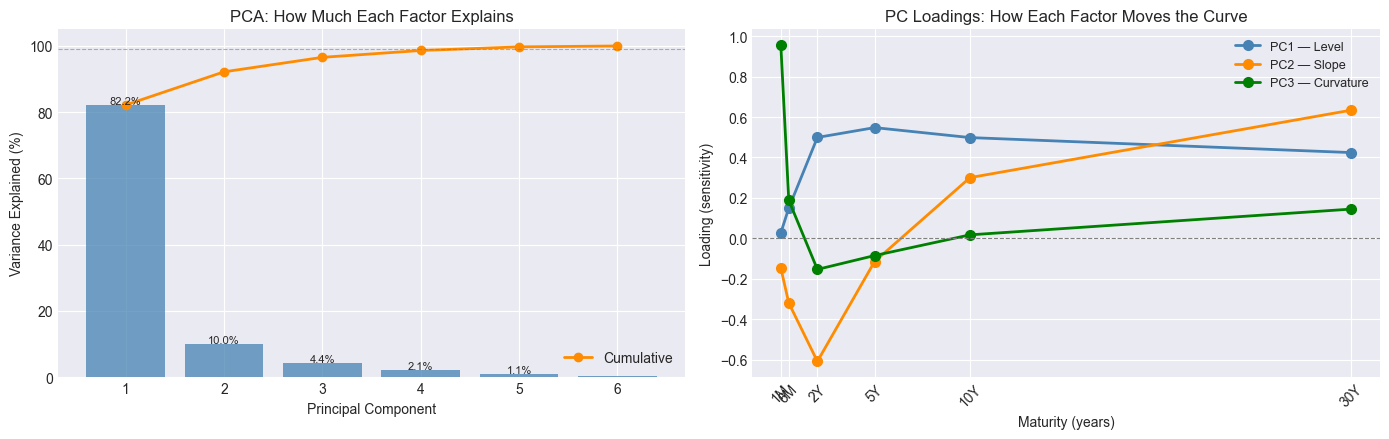

PC1 (Level)     explains 82.2% of all yield curve variance
PC2 (Slope)     explains 10.0%
PC3 (Curvature) explains 4.4%
Total (PC1–3):  96.6%  ← this is our simulation fidelity


In [ ]:
# --- PCA via numpy SVD (no sklearn needed) ---
#
# PCA is just Singular Value Decomposition (SVD) on the centered data matrix.
# SVD decomposes X = U · S · Vᵀ where:
#   Vᵀ (rows) = eigenvectors = our "loading" vectors (how each factor moves each tenor)
#   S (diagonal) = singular values → squared = variance captured by each factor
#   U · S = PC scores (how much each factor moved on each day)
#
# This is exactly what sklearn.decomposition.PCA does internally.

dy_vals    = dy.values                          # (n_days × n_tenors) numpy array
dy_mean    = dy_vals.mean(axis=0)
dy_center  = dy_vals - dy_mean                  # center: subtract mean per tenor

# Full SVD — thin form (full_matrices=False) is sufficient
U, s, Vt = np.linalg.svd(dy_center, full_matrices=False)

# Explained variance: each singular value squared / sum of all squared
var_per_pc  = s ** 2 / (len(dy_vals) - 1)
explained   = var_per_pc / var_per_pc.sum() * 100  # in percent

loadings    = Vt                                # (n_tenors × n_tenors)
pc_scores   = dy_center @ Vt.T                 # (n_days × n_tenors)

N_PCS = 3

# Sign-correct for interpretability (arbitrary convention from SVD)
L = loadings[:N_PCS].copy()
if L[0].mean() < 0:  L[0] *= -1   # PC1: all-positive = level shift up
if L[1][0]    > 0:   L[1] *= -1   # PC2: negative short end = steepening

factor_names = ['PC1 — Level', 'PC2 — Slope', 'PC3 — Curvature']

# --- Plot 1: Explained variance ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
ax.bar(range(1, len(explained)+1), explained, color='steelblue', alpha=0.75)
ax.plot(range(1, len(explained)+1), np.cumsum(explained), 'o-', color='darkorange',
        linewidth=2, label='Cumulative')
ax.axhline(99, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.set_title('PCA: How Much Each Factor Explains')
ax.set_xticks(range(1, len(explained)+1))
ax.legend()
for i, v in enumerate(explained):
    if v > 0.5:
        ax.text(i+1, v+0.3, f'{v:.1f}%', ha='center', fontsize=8)

# --- Plot 2: Factor loading shapes ---
ax2 = axes[1]
for i in range(N_PCS):
    ax2.plot(col_years, L[i], 'o-', label=factor_names[i],
             color=PC_COLORS[i], linewidth=2, markersize=7)

ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax2.set_xlabel('Maturity (years)')
ax2.set_xticks(col_years)
ax2.set_xticklabels(col_labels, rotation=45)
ax2.set_ylabel('Loading (sensitivity)')
ax2.set_title('PC Loadings: How Each Factor Moves the Curve')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"PC1 (Level)     explains {explained[0]:.1f}% of all yield curve variance")
print(f"PC2 (Slope)     explains {explained[1]:.1f}%")
print(f"PC3 (Curvature) explains {explained[2]:.1f}%")
print(f"Total (PC1–3):  {sum(explained[:3]):.1f}%  ← this is our simulation fidelity")

## Step 4: Calibrate Factor Dynamics

Now we know *what* the 3 factors are. We need to know *how they move* day-to-day — specifically, how volatile each one is. That volatility is what drives the spread of simulated paths.

**Model choice: Random walk**

Each PC follows: `PC(t+1) = PC(t) + σᵢ × ε`  where `ε ~ N(0,1)`

We use a **random walk** (no drift, no mean reversion) because:
- PC1 (level) is empirically close to a random walk — rate levels don't reliably mean-revert over 1-year horizons
- It's the most conservative, unbiased assumption for the near term
- Mean reversion is hard to estimate robustly and is unstable across rate regimes

**What we calibrate from history:**
- `σ₁, σ₂, σ₃` — the daily standard deviation of each PC's changes

**Why no correlation matrix between PCs?**

PCA *guarantees* the factors are orthogonal (zero correlation). That's the whole point. Instead of simulating 6+ correlated yield series, we simulate 3 independent factors. Correlation was already "baked in" to the loading shapes themselves.

We also visualize the cumulative factor levels over time — this is the "integrated" version of the PC scores, showing the regimes embedded in your history.

Factor volatility (calibrated from historical daily PC changes):
  PC1 (PC1 — Level         ): σ_daily = 0.1023  |  σ_annual = 1.6235
  PC2 (PC2 — Slope         ): σ_daily = 0.0357  |  σ_annual = 0.5670
  PC3 (PC3 — Curvature     ): σ_daily = 0.0236  |  σ_annual = 0.3747


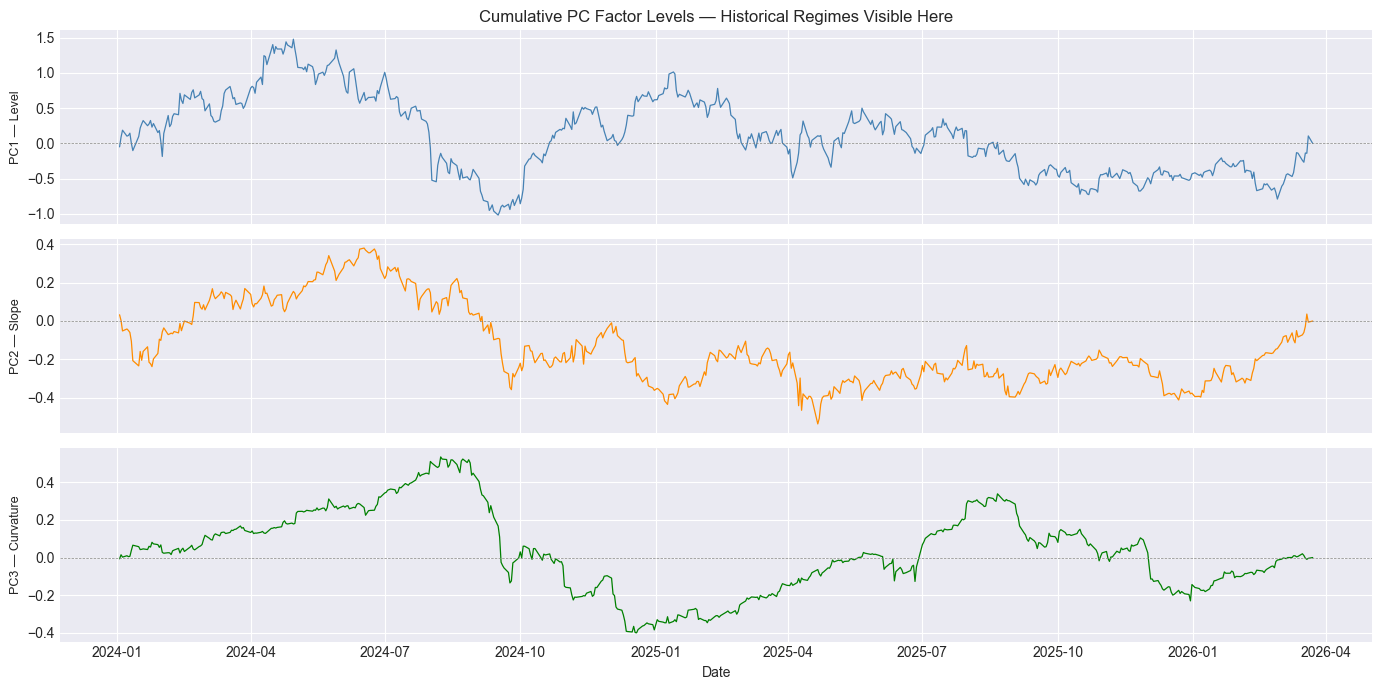


Recent 1Y factor vols (for comparison):
  PC1: 0.0912  (vs full-history: 0.1023)
  PC2: 0.0351  (vs full-history: 0.0357)
  PC3: 0.0230  (vs full-history: 0.0236)


In [ ]:
# PC score time series (daily changes of each factor)
pc_df = pd.DataFrame(
    pc_scores[:, :N_PCS],
    index=dy.index,
    columns=[f'PC{i+1}' for i in range(N_PCS)]
)

# --- Calibrate: daily volatility of each PC ---
pc_vols = pc_df.std()

print("Factor volatility (calibrated from historical daily PC changes):")
for i in range(N_PCS):
    daily  = pc_vols.iloc[i]
    annual = daily * np.sqrt(252)
    print(f"  PC{i+1} ({factor_names[i]:20s}): σ_daily = {daily:.4f}  |  σ_annual = {annual:.4f}")

# --- Visualize cumulative factor levels ---
# Cumsum shows the "accumulated" drift of each factor over time — reveals rate regimes
fig, axes = plt.subplots(N_PCS, 1, figsize=(14, 7), sharex=True)

for i in range(N_PCS):
    cum = pc_df.iloc[:, i].cumsum()
    axes[i].plot(cum.index, cum.values, linewidth=0.9, color=PC_COLORS[i])
    axes[i].set_ylabel(factor_names[i], fontsize=9)
    axes[i].axhline(0, color='gray', linewidth=0.5, linestyle='--')

axes[0].set_title('Cumulative PC Factor Levels — Historical Regimes Visible Here', fontsize=12)
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

# Note on lookback window:
# All history is used by default. If you want to weight recent vol higher,
# you could use an EWMA: pc_df.ewm(span=126).std().iloc[-1]
recent_vols = pc_df.tail(252).std()
print("\nRecent 1Y factor vols (for comparison):")
for i in range(N_PCS):
    print(f"  PC{i+1}: {recent_vols.iloc[i]:.4f}  (vs full-history: {pc_vols.iloc[i]:.4f})")

## Step 5: Monte Carlo Simulation

Now we put it all together and simulate 1,000 possible yield curve futures.

**The algorithm — one path:**
```
Start at today's yield curve
For each trading day (252 days = 1 year):
    Draw random shocks:  ε₁, ε₂, ε₃ ~ N(0,1)
    Scale by volatility: ΔPC₁ = σ₁·ε₁,  ΔPC₂ = σ₂·ε₂,  ΔPC₃ = σ₃·ε₃
    Reconstruct yield changes: Δy = L₁·ΔPC₁ + L₂·ΔPC₂ + L₃·ΔPC₃
    Update yields: y(t+1) = y(t) + Δy
Repeat 1,000 times
```

`L₁, L₂, L₃` are the loading vectors from PCA — they tell us how each PC shock maps back to individual tenor yields.

**What you see in the fan chart:**
- Orange dashed line = today's yield
- Dark band = 25th–75th percentile paths (the "likely" zone)
- Light band = 5th–95th percentile paths (the tail risk zone)
- Blue line = median path

The width of the fan = uncertainty. Longer maturity bonds tend to have wider fans because their yields are more volatile over a 1-year horizon.

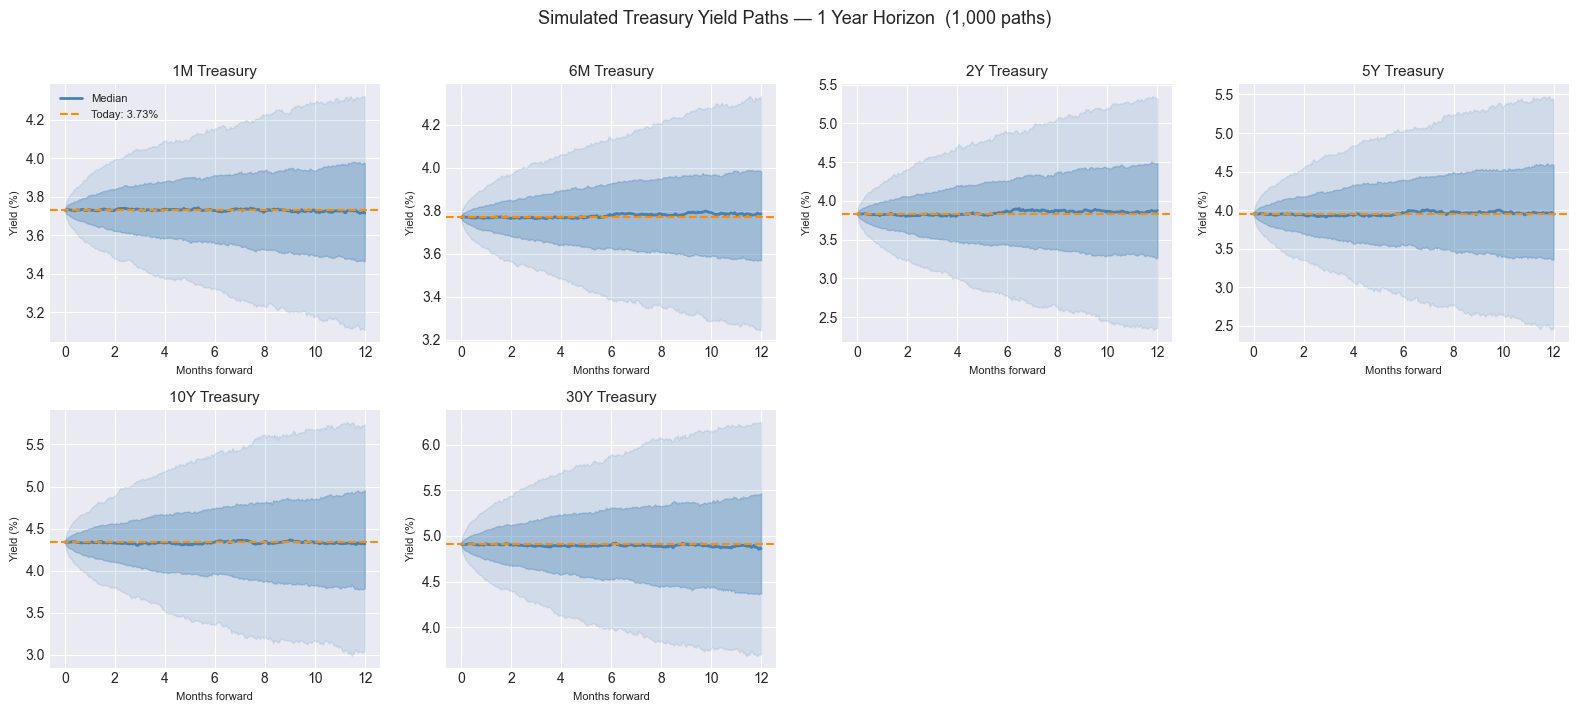

Tenor    Today   Median   Change   5th pct   95th pct
-------------------------------------------------------
1M       3.73%    3.72%   -0.01%     3.11%      4.32%
6M       3.77%    3.79%   +0.02%     3.25%      4.33%
2Y       3.83%    3.88%   +0.05%     2.36%      5.32%
5Y       3.95%    3.95%   -0.00%     2.46%      5.44%
10Y      4.34%    4.32%   -0.02%     3.04%      5.74%
30Y      4.91%    4.86%   -0.05%     3.70%      6.25%


In [ ]:
np.random.seed(42)
N_PATHS  = 1000
N_DAYS   = 252          # 1 trading year
N_TENORS = len(col_labels)

# Today's yield curve — simulation starting point
y0 = df_tsy.iloc[-1].values.copy()

# --- Simulate all paths ---
# all_paths[path, day, tenor] = yield at that point
all_paths = np.zeros((N_PATHS, N_DAYS + 1, N_TENORS))
all_paths[:, 0, :] = y0

for t in range(1, N_DAYS + 1):
    # Independent N(0,1) shocks for each PC (N_PATHS × N_PCS)
    shocks = np.random.standard_normal((N_PATHS, N_PCS))
    
    # Scale by calibrated daily volatility → PC changes
    dpc = shocks * pc_vols.values[:N_PCS]          # (N_PATHS × N_PCS)
    
    # Map PC changes back to yield changes via loadings
    # L shape: (N_PCS × N_TENORS)  →  dpc @ L gives (N_PATHS × N_TENORS)
    dy_sim = dpc @ L
    
    # Advance yields, floor at 0.01% (rates can't go deeply negative in USD)
    all_paths[:, t, :] = np.maximum(all_paths[:, t-1, :] + dy_sim, 0.01)

final_curves = all_paths[:, -1, :]   # shape: (N_PATHS, N_TENORS)

# --- Fan charts: one subplot per tenor ---
n_cols_plot = min(N_TENORS, 4)
n_rows_plot = (N_TENORS + n_cols_plot - 1) // n_cols_plot
fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                         figsize=(n_cols_plot * 4, n_rows_plot * 3.5))
axes = np.array(axes).flatten()
t_months = np.arange(N_DAYS + 1) / 252 * 12

for i, tenor in enumerate(col_labels):
    ax = axes[i]
    paths_i = all_paths[:, :, i]
    p5, p25, p50, p75, p95 = [np.percentile(paths_i, p, axis=0) for p in [5,25,50,75,95]]
    
    ax.fill_between(t_months, p5,  p95,  alpha=0.15, color='steelblue')
    ax.fill_between(t_months, p25, p75,  alpha=0.35, color='steelblue')
    ax.plot(t_months, p50, color='steelblue', linewidth=2, label='Median')
    ax.axhline(y0[i], color='darkorange', linewidth=1.5, linestyle='--',
               label=f'Today: {y0[i]:.2f}%')
    
    ax.set_title(f'{tenor} Treasury', fontsize=11)
    ax.set_xlabel('Months forward', fontsize=8)
    ax.set_ylabel('Yield (%)', fontsize=8)
    if i == 0:
        ax.legend(fontsize=8)

# Hide any unused subplots
for j in range(N_TENORS, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Simulated Treasury Yield Paths — 1 Year Horizon  ({N_PATHS:,} paths)', 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# --- 1-year yield distribution summary ---
print(f"{'Tenor':5s}  {'Today':>7s}  {'Median':>7s}  {'Change':>7s}  {'5th pct':>8s}  {'95th pct':>9s}")
print("-" * 55)
for i, tenor in enumerate(col_labels):
    med = np.median(final_curves[:, i])
    lo  = np.percentile(final_curves[:, i], 5)
    hi  = np.percentile(final_curves[:, i], 95)
    print(f"{tenor:5s}  {y0[i]:>6.2f}%  {med:>6.2f}%  {med-y0[i]:>+6.2f}%  {lo:>7.2f}%  {hi:>8.2f}%")

## Step 6: Total Return Analysis — Where Should You Invest?

For each simulated path we compute the **1-year total return** of buying a par treasury at each tenor and holding it.

**Total Return = Carry + Roll-down + Price Return**

| Component | What it is | Formula |
|-----------|-----------|---------|
| **Carry** | Coupon income from holding the bond for 1 year | `y₀ × 1yr` |
| **Roll-down** | Bond ages: a 10Y becomes a 9Y. If the curve is upward-sloping, the 9Y yield is lower → price rises | `−dur × (y_rolled − y₀)` |
| **Price return** | Yield moved over the year — bond price moves inversely | `−dur × (y_final − y₀)` |

**Modified Duration** for a par bond ≈ `(1 − (1+y)^(−T)) / y`

This is the bond's price sensitivity to a 1% yield move. A 10Y bond at 4.5% has ~8yr duration — meaning if yields rise 1%, you lose ~8% in price. That's what makes long bonds risky.

**Roll-down intuition:**
- **Steep (normal) curve** → roll-down is positive (free extra return just from aging)
- **Flat/inverted curve** → roll-down is zero or negative (aging hurts you)
- Current curve is partially inverted at short end — pay attention to this in results

=== 1-Year Total Return Analysis by Treasury Tenor ===

       Yield Duration Median Return 25th Pct 75th Pct Prob > 0% Prob > 2% Return/Risk
Tenor                                                                                
1M     3.73%    0.1yr        +3.73%   +3.71%   +3.75%      100%      100%    +121.309
6M     3.77%    0.5yr        +3.78%   +3.69%   +3.89%      100%      100%     +24.072
2Y     3.83%    1.9yr        +3.82%   +2.67%   +4.98%       99%       85%      +2.203
5Y     3.95%    4.5yr        +4.13%   +1.27%   +6.77%       83%       69%      +1.009
10Y    4.34%    8.0yr        +5.14%   +0.04%   +9.36%       75%       66%      +0.767
30Y    4.91%   15.5yr        +6.12%   -3.32%  +13.71%       67%       61%      +0.506


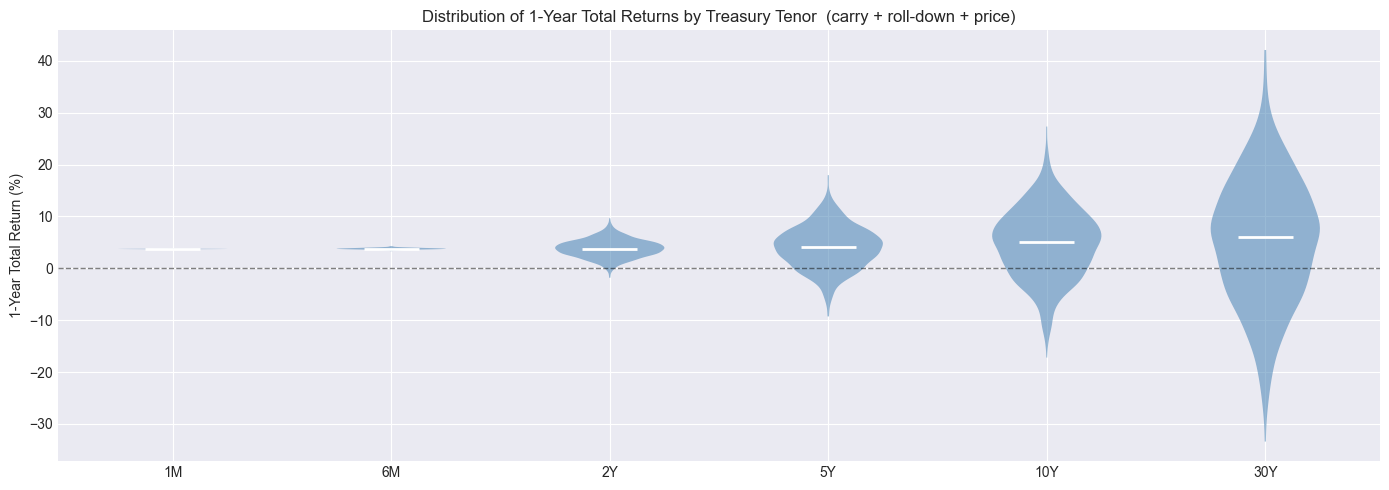

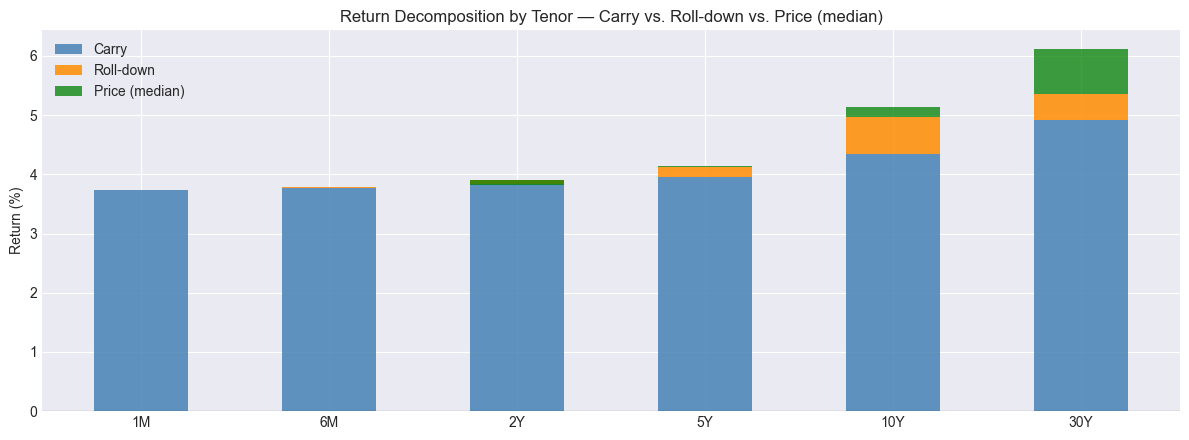

In [ ]:
def modified_duration(yield_pct, maturity_yrs):
    """Modified duration of a par bond (simplified annual coupon formula)."""
    y = yield_pct / 100
    if y < 1e-6 or maturity_yrs < 0.25:
        return maturity_yrs
    return (1 - (1 + y) ** (-maturity_yrs)) / y

def roll_yield(curve_yields, tenors_yrs, bond_tenor, hold_years=1.0):
    """
    Interpolate the yield a bond will have after 'hold_years' of seasoning.
    E.g., a 10Y bond held for 1Y becomes a 9Y bond — what's the 9Y yield today?
    Roll-down gain = -(current 9Y yield - current 10Y yield) × duration
    (lower yield at shorter maturity → price gain if curve is upward-sloping)
    """
    target = bond_tenor - hold_years
    if target <= tenors_yrs[0]:
        return float(curve_yields[0])
    if target >= tenors_yrs[-1]:
        return float(curve_yields[-1])
    f = interpolate.interp1d(tenors_yrs, curve_yields, kind='linear')
    return float(f(target))

# --- Compute total return for every path and every tenor ---
T_hold  = 1.0
returns = np.zeros((N_PATHS, N_TENORS))

for p in range(N_PATHS):
    y_final = all_paths[p, -1, :]

    for i, (tenor, years) in enumerate(zip(col_labels, col_years)):
        y_start  = y0[i]
        y_end    = y_final[i]
        dur      = modified_duration(y_start, years)

        carry      = y_start * T_hold
        y_rolled   = roll_yield(y0, col_years, years, T_hold)
        roll_down  = -dur * (y_rolled - y_start)   # gain if curve slopes up
        price_ret  = -dur * (y_end - y_start)

        returns[p, i] = carry + roll_down + price_ret

# --- Summary table ---
rows = []
for i, tenor in enumerate(col_labels):
    r = returns[:, i]
    rows.append({
        'Tenor':          tenor,
        'Yield':          f"{y0[i]:.2f}%",
        'Duration':       f"{modified_duration(y0[i], col_years[i]):.1f}yr",
        'Median Return':  f"{np.median(r):+.2f}%",
        '25th Pct':       f"{np.percentile(r,25):+.2f}%",
        '75th Pct':       f"{np.percentile(r,75):+.2f}%",
        'Prob > 0%':      f"{(r > 0).mean()*100:.0f}%",
        'Prob > 2%':      f"{(r > 2).mean()*100:.0f}%",
        'Return/Risk':    f"{np.median(r)/r.std():+.3f}",
    })

summary = pd.DataFrame(rows).set_index('Tenor')
print("=== 1-Year Total Return Analysis by Treasury Tenor ===\n")
print(summary.to_string())

# --- Violin plot: full return distribution per tenor ---
fig, ax = plt.subplots(figsize=(14, 5))
parts = ax.violinplot(
    [returns[:, i] for i in range(N_TENORS)],
    positions=range(N_TENORS),
    showmedians=True, showextrema=False
)
for pc in parts['bodies']:
    pc.set_facecolor('steelblue')
    pc.set_alpha(0.55)
parts['cmedians'].set_color('white')
parts['cmedians'].set_linewidth(2)

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xticks(range(N_TENORS))
ax.set_xticklabels(col_labels)
ax.set_ylabel('1-Year Total Return (%)')
ax.set_title('Distribution of 1-Year Total Returns by Treasury Tenor  (carry + roll-down + price)', fontsize=12)
plt.tight_layout()
plt.show()

# --- Median return decomposition bar chart ---
carries    = [y0[i] * T_hold for i in range(N_TENORS)]
roll_downs = [-modified_duration(y0[i], col_years[i]) * (roll_yield(y0, col_years, col_years[i]) - y0[i])
              for i in range(N_TENORS)]
price_rets = [np.median(returns[:, i]) - carries[i] - roll_downs[i] for i in range(N_TENORS)]

x = np.arange(N_TENORS)
w = 0.5
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(x, carries,    w, label='Carry',       color='steelblue',  alpha=0.85)
ax.bar(x, roll_downs, w, bottom=carries,      label='Roll-down',  color='darkorange', alpha=0.85)
ax.bar(x, price_rets, w, bottom=[c+r for c,r in zip(carries, roll_downs)],
                                               label='Price (median)', color='green', alpha=0.75)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(col_labels)
ax.set_ylabel('Return (%)')
ax.set_title('Return Decomposition by Tenor — Carry vs. Roll-down vs. Price (median)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()